<a href="https://colab.research.google.com/github/mojordan235-oss/Project/blob/main/CMP_415_Machine_Learning_MidtermProject_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Midterm Project Part 2



To begin with, load the data frame created in Part 1. You may either repeat Sec. 1 on the original file or save the data frame from Part 1 and load it here.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
part1= pd.read_csv("MidtermProjectPart1.csv")
part1.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985,0
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801,0
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349,0
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562,0
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600,0


## 3. Feature Selection

Feature selection is critical for building effective machine learning models. It helps to reduce the noise in the data, improve model performance, and decrease the computational cost.

3.1 Display the list of feature names (column names).

In [ ]:
print(part1.columns)

Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'hum', 'windspeed', 'cnt', 'year'],
      dtype='object')


3.2 Create new features:
- "is_weekend": indicates whether the day was during a weekend
- Apply one-hot encoding to "season" and "weathersit" using [pd.get_dummies](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html)

Please also remove the feature 'dteday' from the data frame.

In [ ]:
part1['is_weekend']=part1['weekday'].isin([0,6])

display(part1['is_weekend'])

encoding=pd.get_dummies(part1['season'],dtype=float)
encoding1=pd.get_dummies(part1['weathersit'],dtype=float)
display(encoding)

remove=part1.drop(columns=['dteday'])
display(remove)



,is_weekend
0,True
1,True
2,False
3,False
4,False
...,...
726,False
727,False
728,True
729,True


,1,2,3,4
0,1.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0
...,...,...,...,...
726,1.0,0.0,0.0,0.0
727,1.0,0.0,0.0,0.0
728,1.0,0.0,0.0,0.0
729,1.0,0.0,0.0,0.0


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,cnt,year,is_weekend
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446,985,0,True
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539,801,0,True
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309,1349,0,False
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296,1562,0,False
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900,1600,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,0.254167,0.652917,0.350133,2114,1,False
727,1,1,12,0,5,1,2,0.253333,0.590000,0.155471,3095,1,False
728,1,1,12,0,6,0,2,0.253333,0.752917,0.124383,1341,1,True
729,1,1,12,0,0,0,1,0.255833,0.483333,0.350754,1796,1,True


3.3 Calculate the matrix of correlation coefficients between input features and the output feature (the 'cnt' column). Examine the features that has -0.1 < coefficient < 0.1 with the `cnt` column. Decide whether you should remove them from the dataset.

In [ ]:
drop1=part1.drop(columns=['season','weathersit','year','dteday'], errors='ignore')
drop1


correlation=drop1.corr()['cnt']
correlation



,cnt
yr,0.566710
mnth,0.279977
holiday,-0.068348
weekday,0.067443
workingday,0.061156
temp,0.627494
hum,-0.100659
windspeed,-0.234545
cnt,1.000000
is_weekend,-0.037604


In [ ]:
rangecorrelation=correlation[(correlation>-0.1) & (correlation<0.1)]
display(rangecorrelation)

,cnt
holiday,-0.068348
weekday,0.067443
workingday,0.061156
is_weekend,-0.037604


3.4 Data normalization. Apply standard scaling to all **input features**. The output column "cnt" should not be modified. Display the first 5 rows of the transformed dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

cntdrop=part1.drop(columns=['cnt','dteday','yr'])
cntdrop

scaler= StandardScaler()

xscaled=scaler.fit_transform(cntdrop)

xscaled=pd.DataFrame(xscaled,columns=cntdrop.columns)

xscaled.head()


,season,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,year,is_weekend
0,-1.348213,-1.600161,-0.171981,1.498809,-1.471225,1.110427,-0.826662,1.250171,-0.387892,-1.001369,1.575104
1,-1.348213,-1.600161,-0.171981,-1.496077,-1.471225,1.110427,-0.721095,0.479113,0.749602,-1.001369,1.575104
2,-1.348213,-1.600161,-0.171981,-0.996930,0.679706,-0.726048,-1.634657,-1.339274,0.746632,-1.001369,-0.634879
3,-1.348213,-1.600161,-0.171981,-0.497782,0.679706,-0.726048,-1.614780,-0.263182,-0.389829,-1.001369,-0.634879
4,-1.348213,-1.600161,-0.171981,0.001366,0.679706,-0.726048,-1.467414,-1.341494,-0.046307,-1.001369,-0.634879


## 4. Model Building and Evalutaion

After selecting the most relevant features, the next step is to build and evaluate machine learning models.

4.1 Split the dataset into training set, validation set, and test set, with a 70:15:15 ratio.

In [ ]:
from sklearn.model_selection import train_test_split

xtrain,xtemp,ytrain,ytemp=train_test_split(xscaled,part1['cnt'],test_size=0.30)
xval,xtest,yval,ytest=train_test_split(xtemp,ytemp,test_size=0.50)


4.2 Build a linear regression model on the training dataset as the baseline model.

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
model1=LinearRegression()
model1.fit(xtrain,ytrain)
model1prediction=model1.predict(xtest)
model1mse=mean_squared_error(ytest,model1prediction)

print("Mse:",model1mse)


Mse: 854849.5647147038


4.3 Build a degree-2 polynomial regression model with L1 regularization.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

polymodel=PolynomialFeatures(degree=2,include_bias=False)
polyinput=polymodel.fit_transform(xtrain)
model2=LinearRegression()
model2.fit(polyinput,ytrain)
polyinput=polymodel.fit_transform(xtest)
model2prediction=model2.predict(polyinput)
model2mse=mean_squared_error(ytest,model2prediction)

print("Mse:",model2mse)

Mse: 564901.4666996308


4.4 Perform 5-fold cross-validation on both models to ensure that the model's performance is consistent across different subsets of the data.

In [ ]:
from sklearn.model_selection import cross_val_score
model1=LinearRegression()
model1.fit(xtrain,ytrain)
msescores= -cross_val_score(model1,xtrain,ytrain,cv=5,scoring='neg_mean_squared_error')
display("Degree 1 cross val",msescores)

polymodel=PolynomialFeatures(degree=2,include_bias=False)
polyinput=polymodel.fit_transform(xtrain)
msedegree2= -cross_val_score(model2,polyinput,xtrain,cv=5,scoring='neg_mean_squared_error')
display("Degree 2 cross val",msedegree2)

'Degree 1 cross val'

array([769973.60811227, 878042.32958475, 869411.73937905, 879082.68555944,
       685084.61908241])

'Degree 2 cross val'

array([7.55913454e-29, 3.48188578e-29, 1.80109910e-29, 2.88457447e-28,
       1.86478403e-29])

4.5 Model evaluation: Calculate the RMSE of both models on the validation set.

In [ ]:
import numpy as np
ypred=model1.predict(xval)
ypred2=polymodel.fit_transform(xval)
model2prediction=model2.predict(ypred2)

rsmelinear=np.sqrt(mean_squared_error(yval,ypred))
print("RSME",rsmelinear)

rsmelinear=np.sqrt(mean_squared_error(yval,model2prediction))
print("RSME",rsmelinear)

RSME 799.1653062370559
RSME 773.2986469456035


## Phase 5: Model Fine-Tuning

Let's fine-tune the polynomial model to optimize its performance.

5.1 Use grid search to fine-tune the hyperparameters of the polynomial model, including:
- degree of the polynomial
- regularization coefficient `alpha`

**Note:** As these two hyper-parameters are used in different places, `GridSearchCV` may not be directly applicable. You need to use for-loops to example all combinations of values.

In [ ]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline=Pipeline([('poly',PolynomialFeatures()),('model',Ridge())])

param_grid= {
  'poly__degree':[1,2,3,4]
  ,'model__alpha':[0.001,0.01,0.1,1,10]
}

for pg in param_grid:

  gridsearch=GridSearchCV(pipeline,param_grid,cv=5,scoring='neg_mean_squared_error')
  gridsearch.fit(xtrain,ytrain)
  print("Best parameters:",gridsearch.best_params_)


Best parameters: {'model__alpha': 10, 'poly__degree': 2}
Best parameters: {'model__alpha': 10, 'poly__degree': 2}


5.2 Perform 5-fold cross validation on the model with the optimal set of hyperparameter values.

In [ ]:
bestmodel=gridsearch.best_estimator_
msescores= -cross_val_score(bestmodel,xtrain,ytrain,cv=5,scoring='neg_mean_squared_error')

print("Cross Val",msescores)

Cross Val [966167.13749026 581000.92244253 777162.89980152 764622.57182385
 522508.20144435]


5.3 Calculate the RMSE of the final model on the test set.

In [ ]:
ytestpred=bestmodel.predict(xtest)
rsmelinear=np.sqrt(mean_squared_error(yval,ytestpred))
print("RSME",rsmelinear)


RSME 2475.7049896208687


5.4. Compare the above RMSE with the histogram of the 'cnt' column. How would you describe the prediction power of the machine learning model?

'In the graph the count vs temp the count in 2000 range there is lot of plot scatter so the predictuion power of rmse '

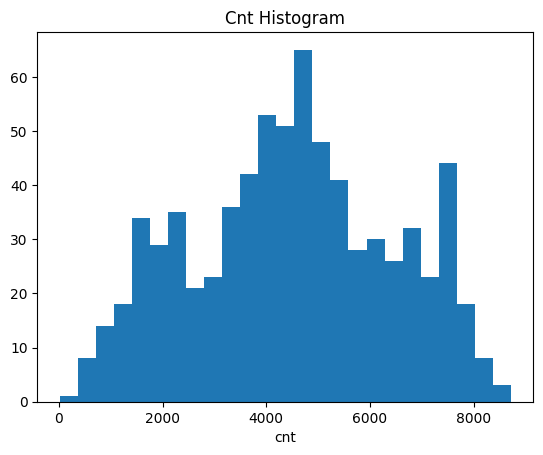

In [ ]:
import matplotlib.pyplot as plt
plt.hist(part1['cnt'], bins=25)

plt.title("Cnt Histogram")
plt.xlabel("cnt")

"In the hsitogram the count in 2000 range there is there litlle of so the predictuion power of rmse is off by little proably "

## Phase 6 (Optional for Undergraduates) SVM Model
Train a SVM regressor with the `SVR` class from `sklearn`. Choose model setting carefully so that the model's performance is optimized. Compare the performance of the SVM model with the polynomial model.